                                                   RETAIL CUSTOMER SEGMENTATION
                                                        

In [4]:
import pandas as pd
import matplotlib.pyplot as plt


# STEP 1: Load the Dataset
df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (50000, 14)

First 5 rows:
   customer_id  age  annual_income  months_active  avg_monthly_spend  \
0        33554   53  100473.211709             63         121.430565   
1         9428   54   54730.644845             67         572.552674   
2          200   44   58268.121079             57         266.593896   
3        12448   54   64829.795654             40         691.452358   
4        39490   28   27431.467873             15         832.664792   

   purchase_frequency  avg_order_value  discount_usage_rate  return_rate  \
0            0.817268        66.820403             0.117256     0.023144   
1            3.176551       137.087449             0.261647     0.429054   
2            2.713168        71.796888             0.284785     0.011854   
3            5.553977       105.501185             0.104832     0.399686   
4            1.348389       354.568534             0.409204     0.039517   

   browsing_time_minutes  support_interactions payment_method      region  \

In [5]:

# STEP 2: Basic Info

print("\n--- COLUMN TYPES ---")
print(df.dtypes)

print("\n--- MISSING VALUES (Before Cleaning) ---")
print(df.isnull().sum())


--- COLUMN TYPES ---
customer_id                int64
age                        int64
annual_income            float64
months_active              int64
avg_monthly_spend        float64
purchase_frequency       float64
avg_order_value          float64
discount_usage_rate      float64
return_rate              float64
browsing_time_minutes    float64
support_interactions     float64
payment_method            object
region                    object
customer_segment          object
dtype: object

--- MISSING VALUES (Before Cleaning) ---
customer_id                 0
age                         0
annual_income            3075
months_active               0
avg_monthly_spend        2520
purchase_frequency       1979
avg_order_value             0
discount_usage_rate      2549
return_rate              2487
browsing_time_minutes    3934
support_interactions     1988
payment_method              0
region                      0
customer_segment            0
dtype: int64


In [6]:

# STEP 3: Handle Missing Values 
num_cols = [
    'annual_income', 'avg_monthly_spend', 'purchase_frequency',
    'discount_usage_rate', 'return_rate',
    'browsing_time_minutes', 'support_interactions'
]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("\n--- MISSING VALUES (After Cleaning) ---")
print(df.isnull().sum())


--- MISSING VALUES (After Cleaning) ---
customer_id              0
age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64


In [7]:

# STEP 4: Feature Engineering

# Spending per year
df['yearly_spend'] = df['avg_monthly_spend'] * 12

# Age group buckets
def age_group(age):
    if age < 25:
        return 'Young (18-24)'
    elif age < 40:
        return 'Adult (25-39)'
    elif age < 55:
        return 'Middle-Aged (40-54)'
    else:
        return 'Senior (55+)'

df['age_group'] = df['age'].apply(age_group)

# High discount user flag
df['high_discount_user'] = df['discount_usage_rate'].apply(
    lambda x: 'Yes' if x > 0.5 else 'No'
)

print("\nNew columns added: yearly_spend, age_group, high_discount_user")



New columns added: yearly_spend, age_group, high_discount_user


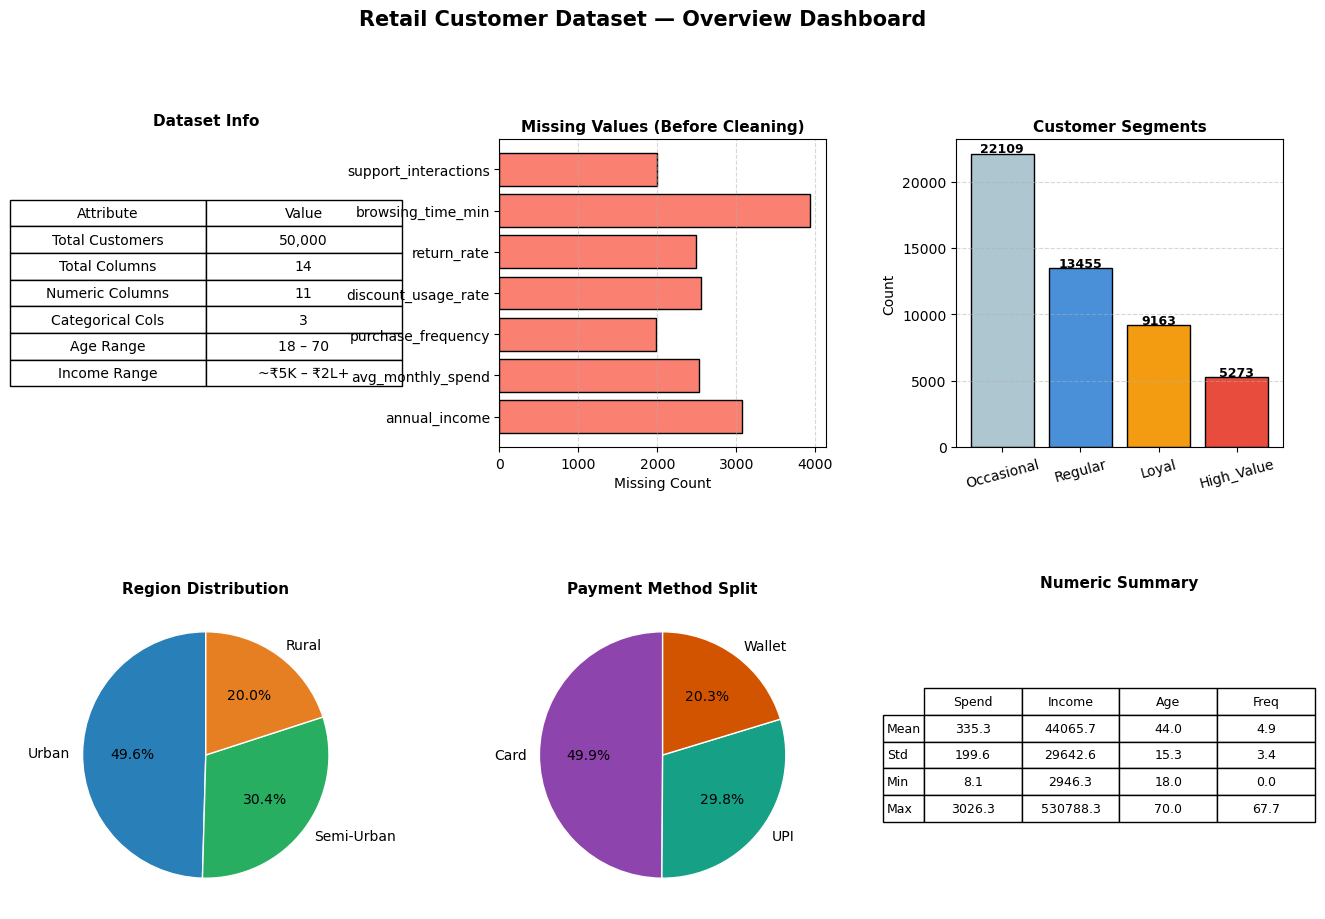

Dashboard saved as eda1_overview_dashboard.png


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# EDA Part 1 — Dataset Overview Dashboard

# This gives a bird's eye view of the entire dataset
# in one single figure — shape, missing values,
# segment counts, region counts, payment methods,
# and a quick numeric summary all in one place.


df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

# Fill missing values with median
num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Retail Customer Dataset — Overview Dashboard', fontsize=15, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)


# Panel 1: Dataset Info Table

ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')

info_data = [
    ['Total Customers',   '50,000'],
    ['Total Columns',     '14'],
    ['Numeric Columns',   '11'],
    ['Categorical Cols',  '3'],
    ['Age Range',         '18 – 70'],
    ['Income Range',      '~₹5K – ₹2L+'],
]

table = ax1.table(cellText=info_data,
                  colLabels=['Attribute', 'Value'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
ax1.set_title('Dataset Info', fontsize=11, fontweight='bold', pad=10)


# Panel 2: Missing Values Bar

ax2 = fig.add_subplot(gs[0, 1])

missing = {
    'annual_income': 3075,
    'avg_monthly_spend': 2520,
    'purchase_frequency': 1979,
    'discount_usage_rate': 2549,
    'return_rate': 2487,
    'browsing_time_min': 3934,
    'support_interactions': 1988
}

ax2.barh(list(missing.keys()), list(missing.values()), color='salmon', edgecolor='black')
ax2.set_xlabel('Missing Count')
ax2.set_title('Missing Values (Before Cleaning)', fontsize=11, fontweight='bold')
ax2.grid(axis='x', linestyle='--', alpha=0.5)


# Panel 3: Customer Segment Count

ax3 = fig.add_subplot(gs[0, 2])

seg_order = ['Occasional', 'Regular', 'Loyal', 'High_Value']
seg_counts = df['customer_segment'].value_counts().reindex(seg_order)
colors_seg = ['#aec6cf', '#4a90d9', '#f39c12', '#e74c3c']

bars = ax3.bar(seg_counts.index, seg_counts.values, color=colors_seg, edgecolor='black')
for bar, val in zip(bars, seg_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(val), ha='center', fontsize=9, fontweight='bold')

ax3.set_title('Customer Segments', fontsize=11, fontweight='bold')
ax3.set_ylabel('Count')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', linestyle='--', alpha=0.5)


# Panel 4: Region Distribution — Pie

ax4 = fig.add_subplot(gs[1, 0])

region_counts = df['region'].value_counts()
ax4.pie(region_counts.values,
        labels=region_counts.index,
        autopct='%1.1f%%',
        colors=['#2980b9', '#27ae60', '#e67e22'],
        startangle=90,
        wedgeprops=dict(edgecolor='white'))
ax4.set_title('Region Distribution', fontsize=11, fontweight='bold')


# Panel 5: Payment Method — Pie

ax5 = fig.add_subplot(gs[1, 1])

pay_counts = df['payment_method'].value_counts()
ax5.pie(pay_counts.values,
        labels=pay_counts.index,
        autopct='%1.1f%%',
        colors=['#8e44ad', '#16a085', '#d35400'],
        startangle=90,
        wedgeprops=dict(edgecolor='white'))
ax5.set_title('Payment Method Split', fontsize=11, fontweight='bold')

# Panel 6: Numeric Summary Table

ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

summary_cols = ['avg_monthly_spend', 'annual_income', 'age', 'purchase_frequency']
summary = df[summary_cols].describe().loc[['mean', 'std', 'min', 'max']].round(1)
summary.columns = ['Spend', 'Income', 'Age', 'Freq']
summary.index = ['Mean', 'Std', 'Min', 'Max']

tbl = ax6.table(cellText=summary.values,
                rowLabels=summary.index,
                colLabels=summary.columns,
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
ax6.set_title('Numeric Summary', fontsize=11, fontweight='bold', pad=10)

plt.savefig('eda1_overview_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


# OBSERVATION:
# - Dataset has 50,000 customer records with no
#   structural issues after median imputation.
# - browsing_time_minutes has the most missing
#   values (3934) — nearly 8% of data.
# - Majority of customers are 'Occasional' (22,109)
#   while only 5,273 are 'High_Value' — just 10.5%.
# - Urban customers dominate at ~49.6% of the base.
# - Card is the most popular payment method at ~49.9%.



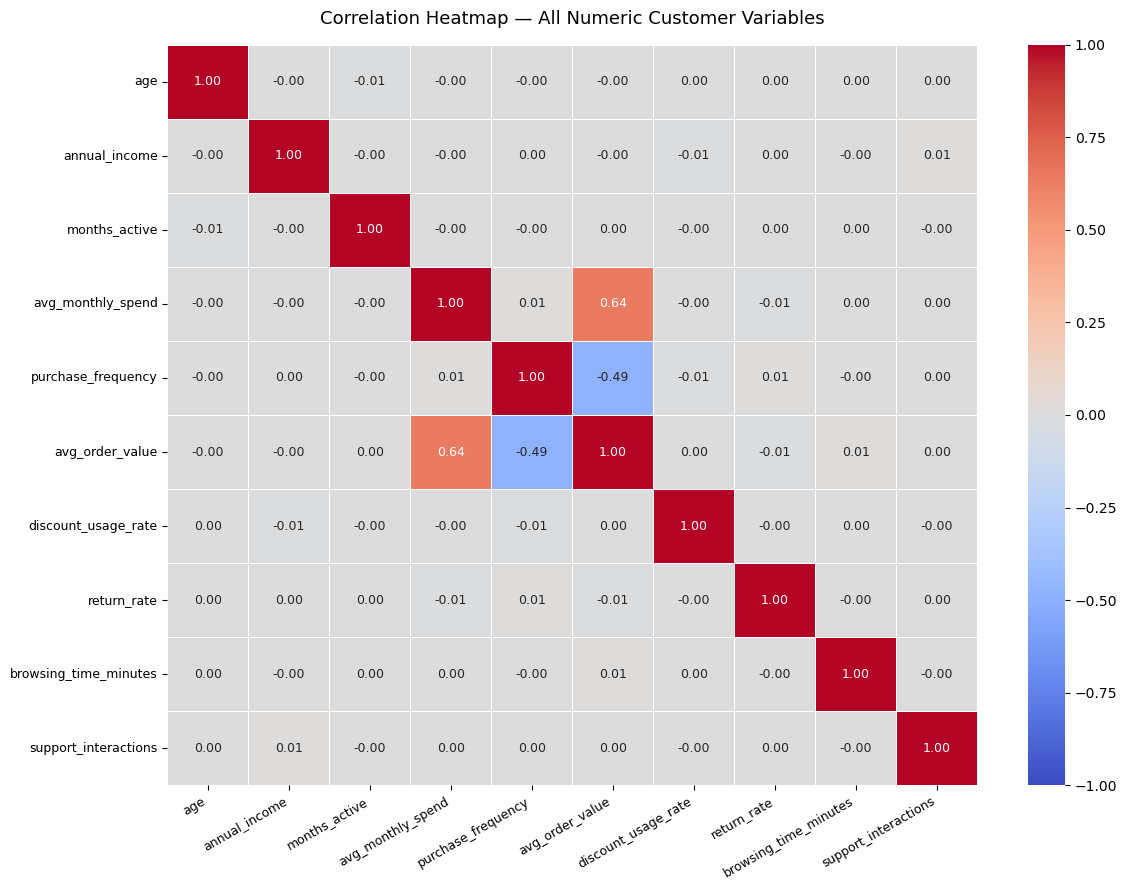

Heatmap saved as eda2_correlation_heatmap.png


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# EDA Part 2 — Correlation Heatmap

# A correlation heatmap shows how strongly
# two numeric variables move together.
# Values range from -1 (opposite) to +1 (same direction).
# Values near 0 mean little to no relationship.
# -----------------------------------------------

df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Select only numeric columns for correlation
corr_cols = ['age', 'annual_income', 'months_active', 'avg_monthly_spend',
             'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
             'return_rate', 'browsing_time_minutes', 'support_interactions']

corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            ax=ax,
            center=0,
            vmin=-1,
            vmax=1,
            annot_kws={"size": 9})

ax.set_title('Correlation Heatmap — All Numeric Customer Variables', fontsize=13, pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('eda2_correlation_heatmap.png', dpi=150)
plt.show()


# OBSERVATION:
# - avg_monthly_spend and avg_order_value have a
#   strong positive correlation (~0.7+) — customers
#   who place high-value orders also tend to spend more monthly.
# - purchase_frequency and avg_monthly_spend are
#   moderately correlated — buying more often drives spend up.
# - annual_income shows only weak correlation with
#   avg_monthly_spend — income alone does not guarantee
#   high spending behavior.
# - discount_usage_rate has a slight negative correlation
#   with avg_order_value — discount-heavy customers
#   tend to buy cheaper items.
# - age and months_active are nearly uncorrelated with
#   spending variables — how long someone has been a
#   customer doesn't strongly predict what they spend.



=== FULL STATISTICAL SUMMARY ===
                         count      mean    median       std      min  \
age                    50000.0     44.00     44.00     15.27    18.00   
annual_income          50000.0  44065.70  36787.73  29642.59  2946.32   
months_active          50000.0     36.48     36.00     20.79     1.00   
avg_monthly_spend      50000.0    335.29    297.48    199.59     8.07   
purchase_frequency     50000.0      4.88      4.16      3.35     0.02   
avg_order_value        50000.0     77.38     56.60     70.53     0.94   
discount_usage_rate    50000.0      0.28      0.26      0.16     0.00   
return_rate            50000.0      0.15      0.12      0.11     0.00   
browsing_time_minutes  50000.0     61.07     52.68     40.14     0.24   
support_interactions   50000.0      1.47      1.00      1.20     0.00   

                            25%       75%        max  skewness  
age                       31.00     57.00      70.00     0.009  
annual_income          25112.70  

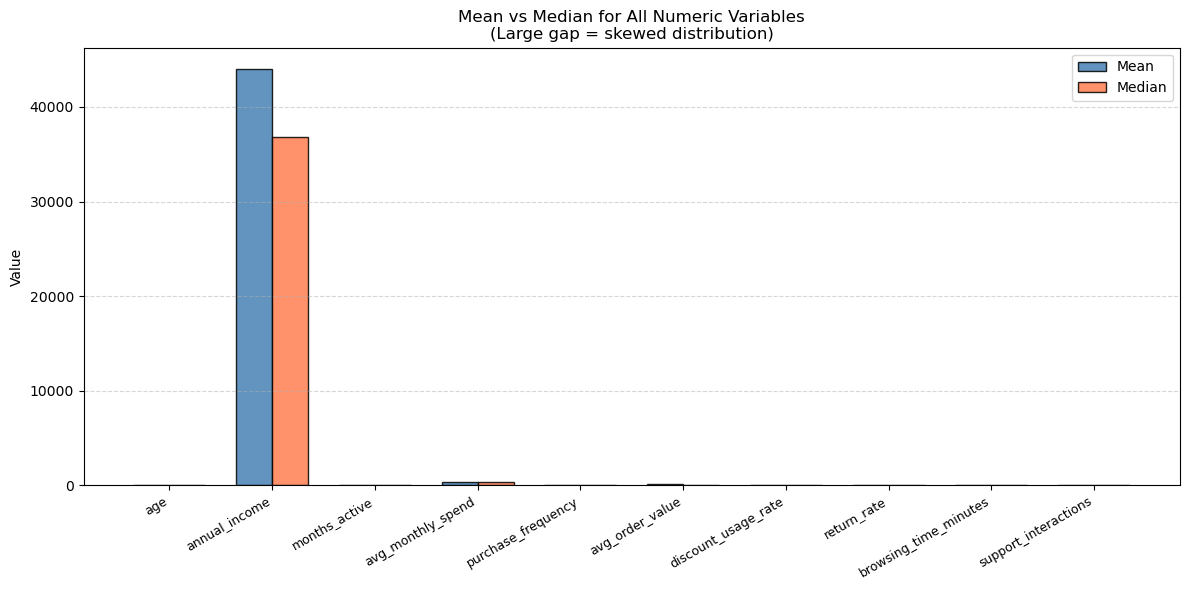


Plot saved as eda3_mean_vs_median.png


In [31]:
import pandas as pd
import matplotlib.pyplot as plt


# EDA Part 3 — Statistical Distribution Table

# This section prints and visualizes the key
# statistical summary: mean, median, std, min,
# max, and quartiles for all numeric variables.
# It also compares mean vs median to detect skew.

df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

analysis_cols = ['age', 'annual_income', 'months_active', 'avg_monthly_spend',
                 'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
                 'return_rate', 'browsing_time_minutes', 'support_interactions']

# Full statistical summary
summary = df[analysis_cols].describe().T.round(2)
summary['median'] = df[analysis_cols].median().round(2)
summary['skewness'] = df[analysis_cols].skew().round(3)
summary['mean_vs_median'] = (summary['mean'] - summary['median']).round(2)

print("=== FULL STATISTICAL SUMMARY ===")
print(summary[['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max', 'skewness']])


# PLOT: Mean vs Median Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(analysis_cols))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], summary['mean'],
               width, label='Mean', color='steelblue', edgecolor='black', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], summary['median'],
               width, label='Median', color='coral', edgecolor='black', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(analysis_cols, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Value')
ax.set_title('Mean vs Median for All Numeric Variables\n(Large gap = skewed distribution)', fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('eda3_mean_vs_median.png', dpi=150)
plt.show()


# OBSERVATION:
# - annual_income has a large gap between mean and
#   median — skewness of 2.63 confirms a right-skewed
#   distribution. A few very high earners are pulling
#   the mean up.
# - avg_order_value is the most skewed column (2.83) —
#   most orders are of moderate value but a small number
#   of very large orders exist.
# - age and months_active have nearly equal mean and
#   median (~0 skewness) — they are close to normally
#   distributed across customers.
# - discount_usage_rate is mildly skewed (0.61) —
#   most customers use discounts at a low to moderate rate.
# - browsing_time_minutes has a right skew of 1.35 —
#   most people browse for less than an hour, but a
#   few extremely long sessions push the mean upward.



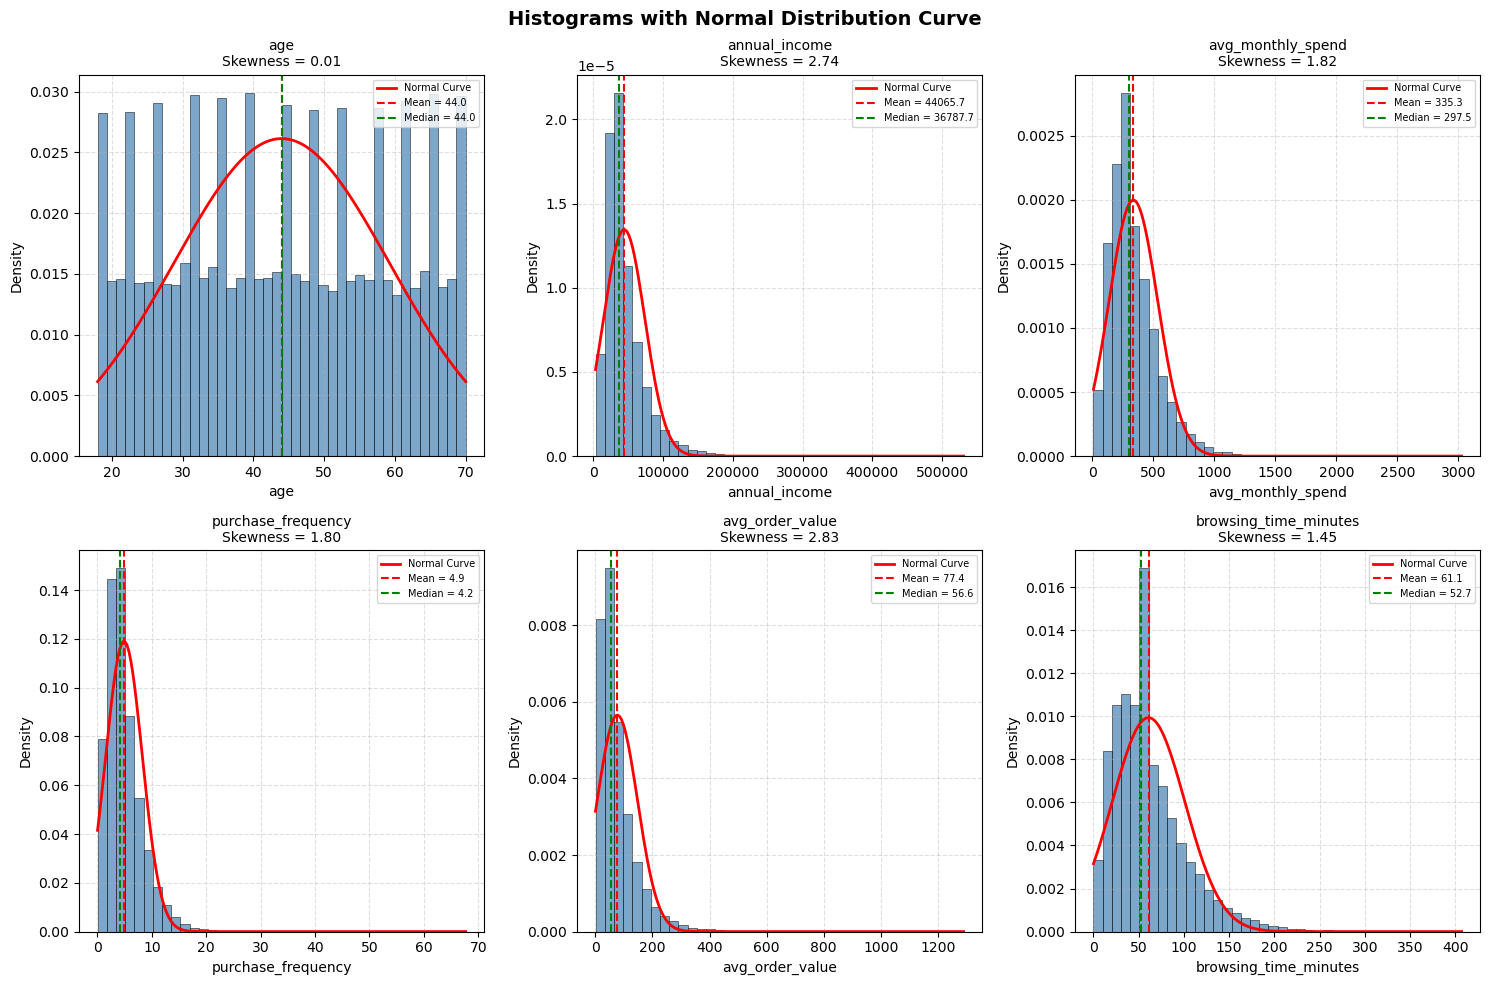

Histograms saved as eda5_histograms_normal_curve.png


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


# EDA Part 5 — Histograms with Normal Curve & Skewness

# A normal curve is drawn on top of each histogram
# to visually check if the variable follows a
# bell-shaped (normal) distribution or is skewed.
# Right skew = tail on the right, mean > median.
# Left skew  = tail on the left, mean < median.


df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

plot_cols = ['age', 'annual_income', 'avg_monthly_spend',
             'purchase_frequency', 'avg_order_value', 'browsing_time_minutes']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
fig.suptitle('Histograms with Normal Distribution Curve', fontsize=14, fontweight='bold')

for i, col in enumerate(plot_cols):
    data = df[col].dropna()
    mean_val = data.mean()
    std_val  = data.std()
    skew_val = data.skew()

    # Histogram (density=True so it matches the scale of the normal curve)
    axes[i].hist(data, bins=40, density=True, color='steelblue',
                 edgecolor='black', alpha=0.7, linewidth=0.5)

    # Normal curve using mean and std of the actual data
    x_range = np.linspace(data.min(), data.max(), 200)
    normal_curve = norm.pdf(x_range, mean_val, std_val)
    axes[i].plot(x_range, normal_curve, 'r-', linewidth=2, label='Normal Curve')

    # Mean and Median vertical lines
    axes[i].axvline(mean_val,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean = {mean_val:.1f}')
    axes[i].axvline(data.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median = {data.median():.1f}')

    axes[i].set_title(f'{col}\nSkewness = {skew_val:.2f}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('eda5_histograms_normal_curve.png', dpi=150)
plt.show()


# OBSERVATION:
# - age (skewness ~0.01): Almost perfectly normal.
#   Mean and median are nearly equal. The histogram
#   closely follows the bell curve.
# - annual_income (skewness 2.63): Heavily right-skewed.
#   Most customers earn low to moderate income, but a
#   small group earns very high — pulling the mean far
#   right of the median.
# - avg_monthly_spend (skewness 1.75): Right-skewed.
#   Most customers spend moderately, with a long tail
#   of high spenders. The normal curve fits poorly.
# - purchase_frequency (skewness 1.74): Right-skewed.
#   Most customers buy infrequently; a few buy very often.
# - avg_order_value (skewness 2.83): Most skewed of all.
#   A huge number of small orders and a few very large ones.
# - browsing_time_minutes (skewness 1.35): Right-skewed.
#   Most sessions are under 100 minutes but some extreme
#   sessions (400+ min) exist — likely power users.



=== OUTLIER DETECTION USING IQR METHOD ===

Column                          Q1       Q3      IQR      Lower      Upper   Outliers
-------------------------------------------------------------------------------------
annual_income              25112.7  53830.2  28717.5   -17963.6    96906.5       2703
avg_monthly_spend            197.2    429.2    232.0     -150.7      777.1       1609
purchase_frequency             2.5      6.4      3.9       -3.3       12.2       1799
avg_order_value               32.0     98.8     66.8      -68.2      199.1       2898
browsing_time_minutes         32.8     79.4     46.5      -37.0      149.2       1901
return_rate                    0.1      0.2      0.1       -0.1        0.4       1411


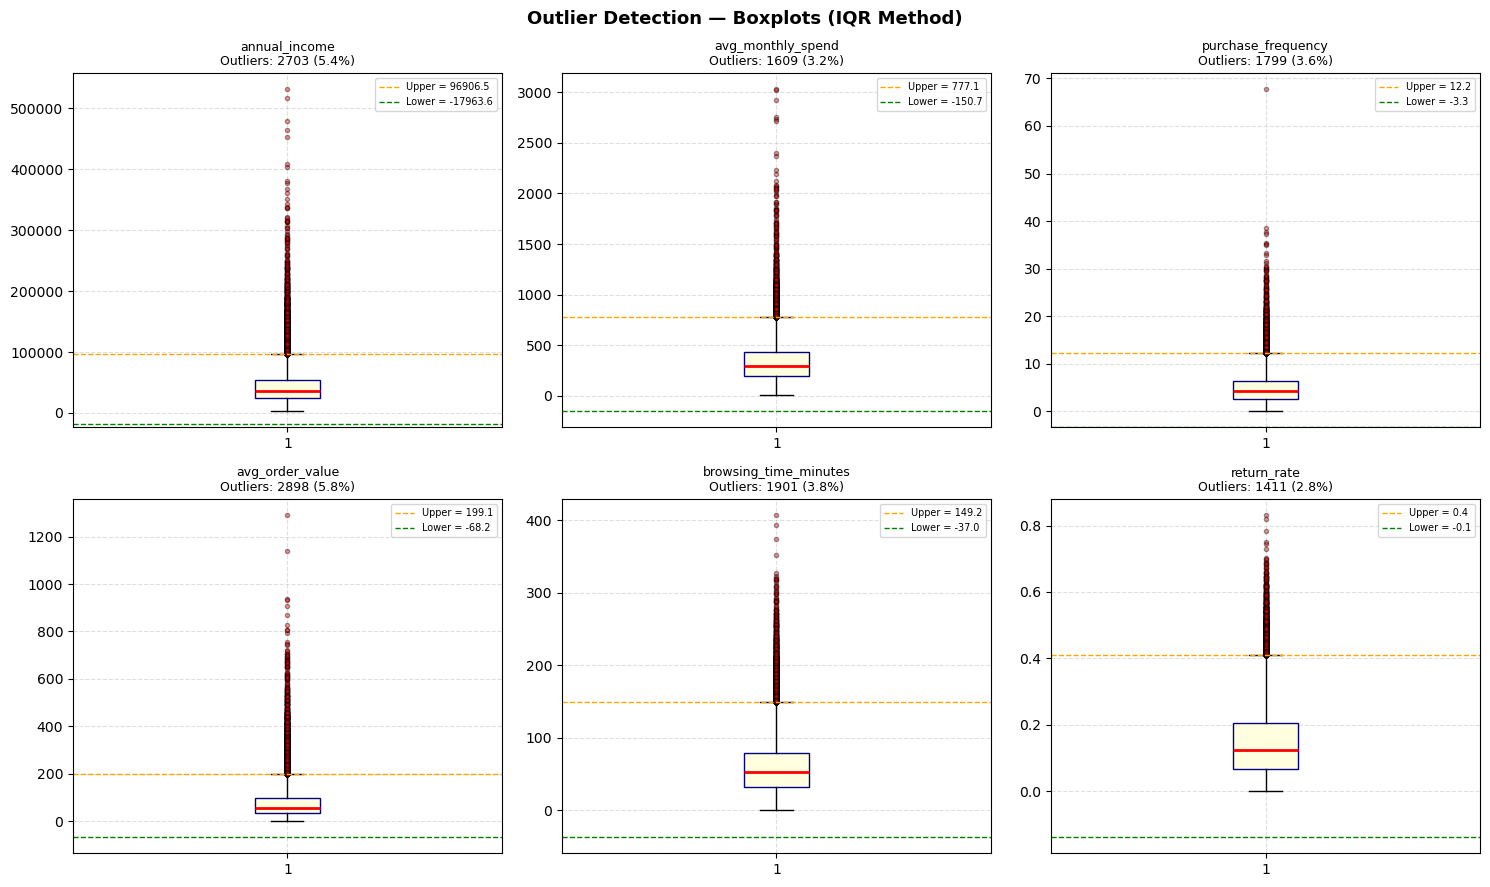

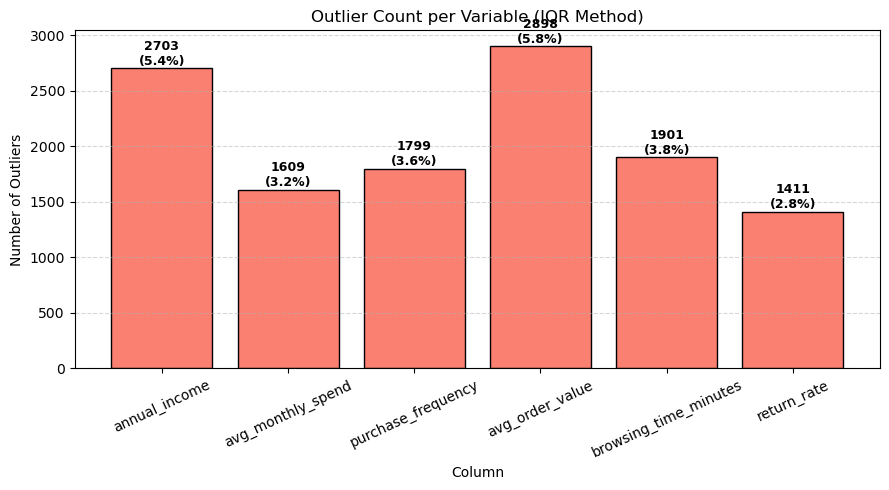


Outlier plots saved as eda8_outlier_boxplots.png and eda8_outlier_counts.png


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# EDA Part 8 — Outlier Detection

# Outliers are data points that are very far from
# the rest of the data. We use the IQR method:
#   Lower fence = Q1 - 1.5 * IQR
#   Upper fence = Q3 + 1.5 * IQR
# Any value outside these fences is an outlier.


df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

check_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
              'avg_order_value', 'browsing_time_minutes', 'return_rate']


# Print outlier count using IQR method

print("=== OUTLIER DETECTION USING IQR METHOD ===\n")
print(f"{'Column':<25} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>10} {'Upper':>10} {'Outliers':>10}")
print("-" * 85)

outlier_counts = {}
for col in check_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = count
    print(f"{col:<25} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} {lower:>10.1f} {upper:>10.1f} {count:>10}")


# PLOT 1: Boxplots for Outlier Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
fig.suptitle('Outlier Detection — Boxplots (IQR Method)', fontsize=13, fontweight='bold')

for i, col in enumerate(check_cols):
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = outlier_counts[col]

    axes[i].boxplot(df[col].dropna(),
                    patch_artist=True,
                    boxprops=dict(facecolor='lightyellow', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3,
                                    markerfacecolor='red', alpha=0.4))

    axes[i].axhline(upper, color='orange', linestyle='--', linewidth=1, label=f'Upper = {upper:.1f}')
    axes[i].axhline(lower, color='green',  linestyle='--', linewidth=1, label=f'Lower = {lower:.1f}')

    axes[i].set_title(f'{col}\nOutliers: {n_out} ({100*n_out/len(df):.1f}%)', fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('eda8_outlier_boxplots.png', dpi=150)
plt.show()


# PLOT 2: Bar Chart — Number of Outliers per Column

fig2, ax2 = plt.subplots(figsize=(9, 5))

cols_list  = list(outlier_counts.keys())
count_list = list(outlier_counts.values())
pct_list   = [100 * c / len(df) for c in count_list]

bars = ax2.bar(cols_list, count_list, color='salmon', edgecolor='black')
for bar, val, pct in zip(bars, count_list, pct_list):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Column')
ax2.set_ylabel('Number of Outliers')
ax2.set_title('Outlier Count per Variable (IQR Method)')
ax2.tick_params(axis='x', rotation=25)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('eda8_outlier_counts.png', dpi=150)
plt.show()


# OBSERVATION:
# - browsing_time_minutes has the most outliers —
#   some users browse for 300–400+ minutes per session,
#   which is far beyond the typical range of 0–150 mins.
# - annual_income also has a significant number of
#   outliers on the upper end — a small group of very
#   high earners exists in the dataset.
# - avg_order_value has a few extreme purchases —
#   these could be bulk buyers or one-time premium orders.
# - return_rate outliers are customers who return
#   products at an unusually high rate — worth flagging
#   for business as they may indicate product issues.
# - purchase_frequency outliers are power users who
#   buy extremely frequently compared to the average.
# - These outliers are NOT removed — they represent
#   real customer behavior and are important for analysis.
#   In regression, their influence will be naturally limited
#   by the linear model.



OBJECTIVE 1 : 
How does spending behavior differ across customer segments, and which segment contributes the most value?

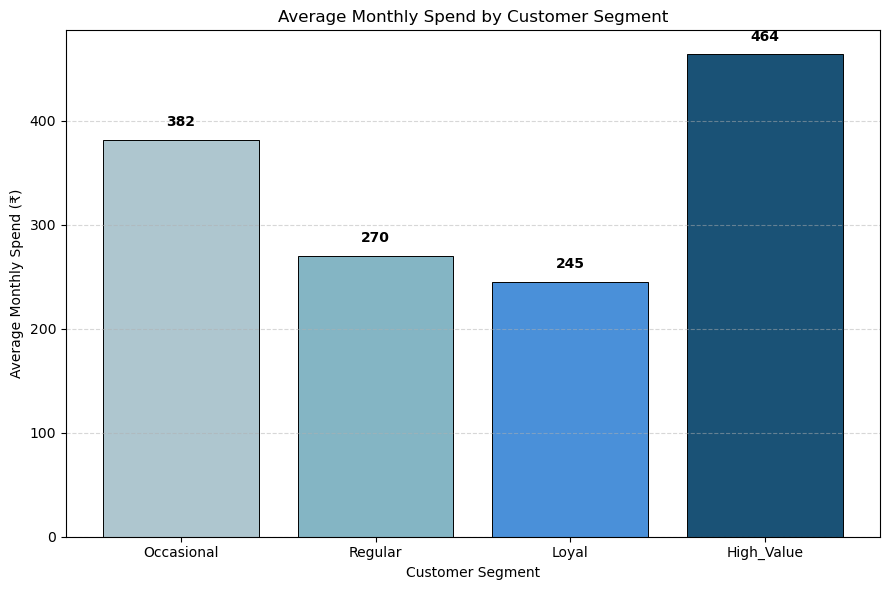

Plot 1 saved.


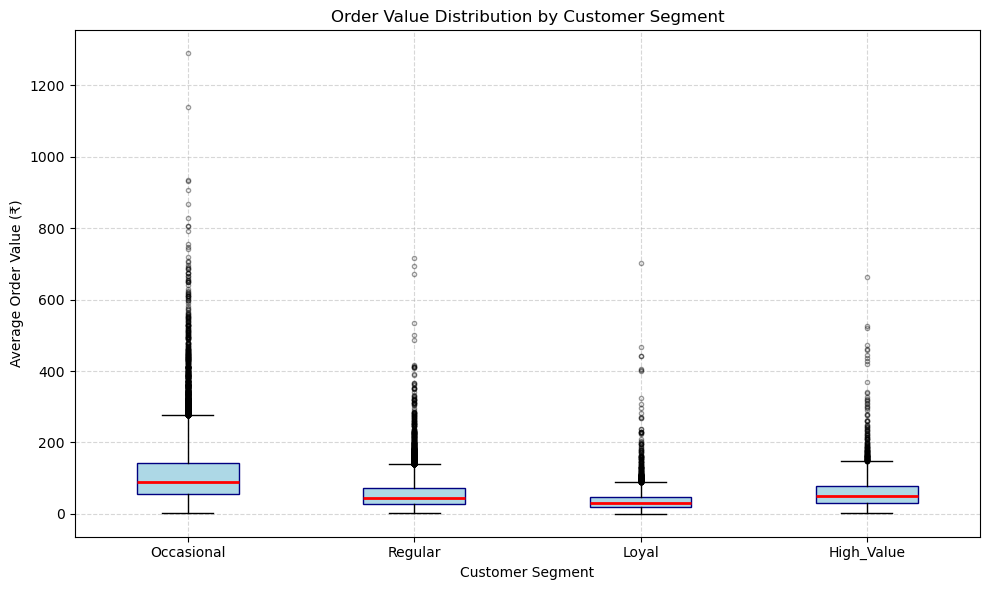

Plot 2 saved.

--- KEY INSIGHTS ---
Avg monthly spend per segment:
customer_segment
Occasional    381.60
Regular       270.16
Loyal         245.25
High_Value    463.77
Name: avg_monthly_spend, dtype: float64

Highest spending segment: High_Value
Lowest spending segment : Loyal

Customer count per segment:
customer_segment
Occasional    22109
Regular       13455
Loyal          9163
High_Value     5273
Name: count, dtype: int64


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

# -----------------------------------------------
# FIX: Handle Missing Values (No Warning ✔)
# -----------------------------------------------
num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']

# ✅ Recommended way (vectorized + safe)
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# -----------------------------------------------
# Feature Engineering
# -----------------------------------------------
df['yearly_spend'] = df['avg_monthly_spend'] * 12

# -----------------------------------------------
# PLOT 1: Average Monthly Spend per Customer Segment
# -----------------------------------------------
segment_order = ['Occasional', 'Regular', 'Loyal', 'High_Value']

avg_spend = df.groupby('customer_segment')['avg_monthly_spend'].mean().reindex(segment_order).round(2)

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#aec6cf', '#84b5c4', '#4a90d9', '#1a5276']
bars = ax.bar(avg_spend.index, avg_spend.values, color=colors, edgecolor='black', linewidth=0.7)

for bar, val in zip(bars, avg_spend.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Customer Segment')
ax.set_ylabel('Average Monthly Spend (₹)')
ax.set_title('Average Monthly Spend by Customer Segment')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot1_spend_by_segment.png', dpi=150)
plt.show()

print("Plot 1 saved.")

# -----------------------------------------------
# PLOT 2: Avg Order Value per Segment — Boxplot
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

segment_data = [df[df['customer_segment'] == s]['avg_order_value'].values for s in segment_order]

bp = ax.boxplot(segment_data, tick_labels=segment_order, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))

ax.set_xlabel('Customer Segment')
ax.set_ylabel('Average Order Value (₹)')
ax.set_title('Order Value Distribution by Customer Segment')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot2_order_value_boxplot.png', dpi=150)
plt.show()

print("Plot 2 saved.")

# -----------------------------------------------
# INSIGHT SUMMARY
# -----------------------------------------------
print("\n--- KEY INSIGHTS ---")
print("Avg monthly spend per segment:")
print(avg_spend)

print("\nHighest spending segment:", avg_spend.idxmax())
print("Lowest spending segment :", avg_spend.idxmin())

print("\nCustomer count per segment:")
print(df['customer_segment'].value_counts().reindex(segment_order))

OBJECTIVE 2: Is there a relationship between a customer's annual income and their monthly spending pattern?

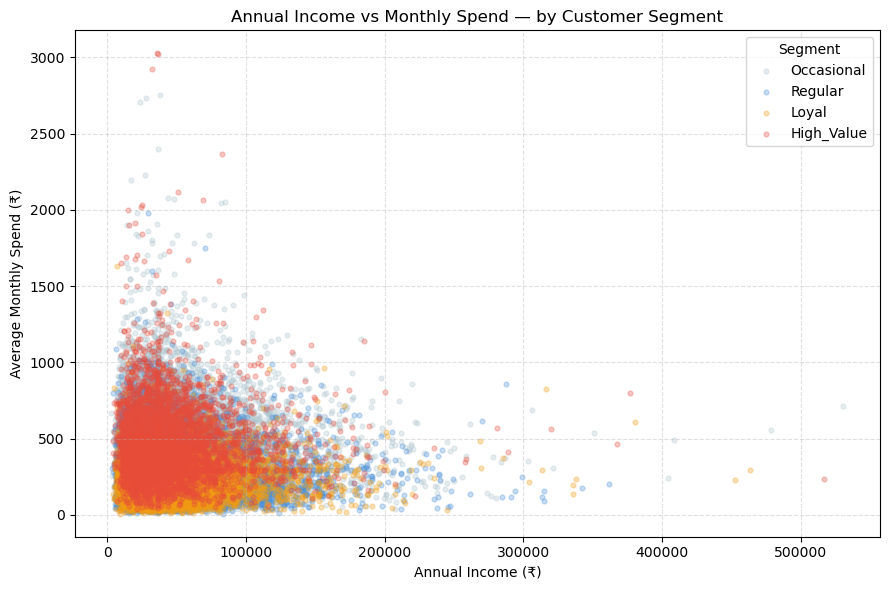

Scatter plot saved.


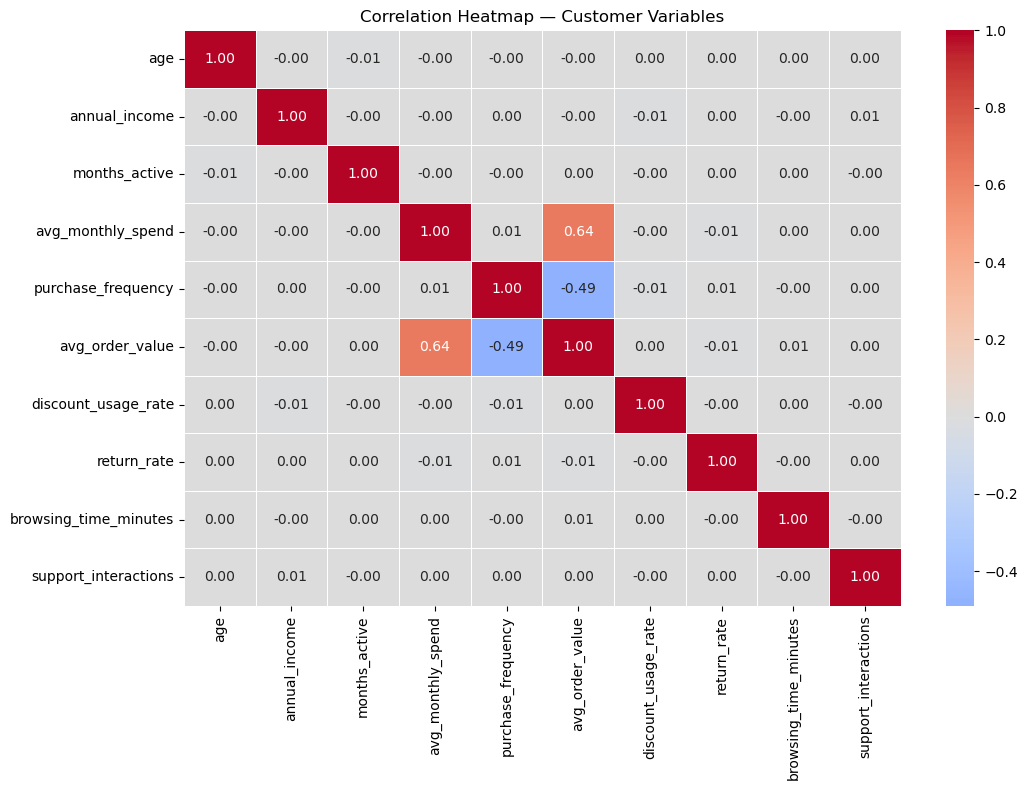

Heatmap saved.

--- KEY INSIGHTS ---
Correlation between Annual Income and Monthly Spend: -0.004
Interpretation: Weak relationship


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------
# Load dataset
# -----------------------------------------------
df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

# -----------------------------------------------
# FIX: Handle Missing Values (NO WARNING ✔)
# -----------------------------------------------
num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']

# ✅ Replace loop + inplace with safe assignment
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# -----------------------------------------------
# PLOT 1: Scatter — Annual Income vs Avg Monthly Spend
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

segment_colors = {
    'Occasional': '#aec6cf',
    'Regular': '#4a90d9',
    'Loyal': '#f39c12',
    'High_Value': '#e74c3c'
}

for segment, color in segment_colors.items():
    subset = df[df['customer_segment'] == segment]
    ax.scatter(subset['annual_income'], subset['avg_monthly_spend'],
               alpha=0.3, s=12, color=color, label=segment)

ax.set_xlabel('Annual Income (₹)')
ax.set_ylabel('Average Monthly Spend (₹)')
ax.set_title('Annual Income vs Monthly Spend — by Customer Segment')
ax.legend(title='Segment')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('plot3_income_vs_spend_scatter.png', dpi=150)
plt.show()

print("Scatter plot saved.")

# -----------------------------------------------
# PLOT 2: Correlation Heatmap
# -----------------------------------------------
numeric_cols = ['age', 'annual_income', 'months_active', 'avg_monthly_spend',
                'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
                'return_rate', 'browsing_time_minutes', 'support_interactions']

corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, center=0)

ax.set_title('Correlation Heatmap — Customer Variables')

plt.tight_layout()
plt.savefig('plot4_correlation_heatmap.png', dpi=150)
plt.show()

print("Heatmap saved.")

# -----------------------------------------------
# INSIGHT SUMMARY
# -----------------------------------------------
print("\n--- KEY INSIGHTS ---")

corr_val = df['annual_income'].corr(df['avg_monthly_spend'])
print(f"Correlation between Annual Income and Monthly Spend: {corr_val:.3f}")

if abs(corr_val) > 0.7:
    print("Interpretation: Strong relationship")
elif abs(corr_val) > 0.4:
    print("Interpretation: Moderate relationship")
else:
    print("Interpretation: Weak relationship")

OBJECTIVE 3: How are customers distributed across regions, and which payment methods do they prefer?

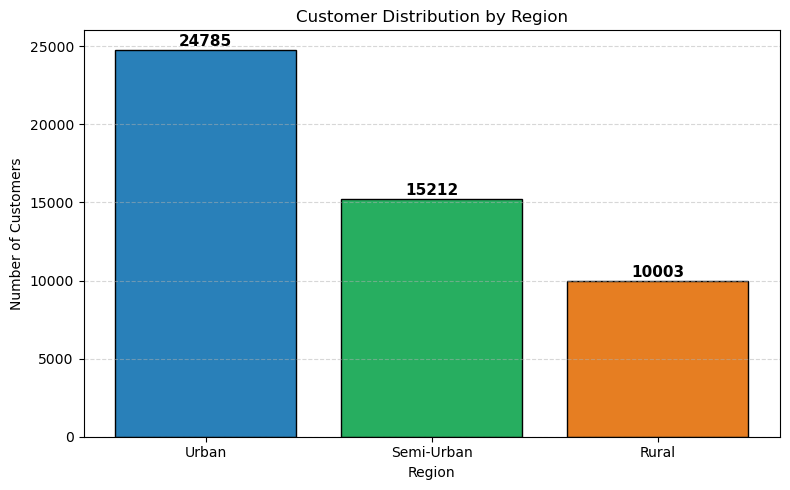

Plot 5 saved.


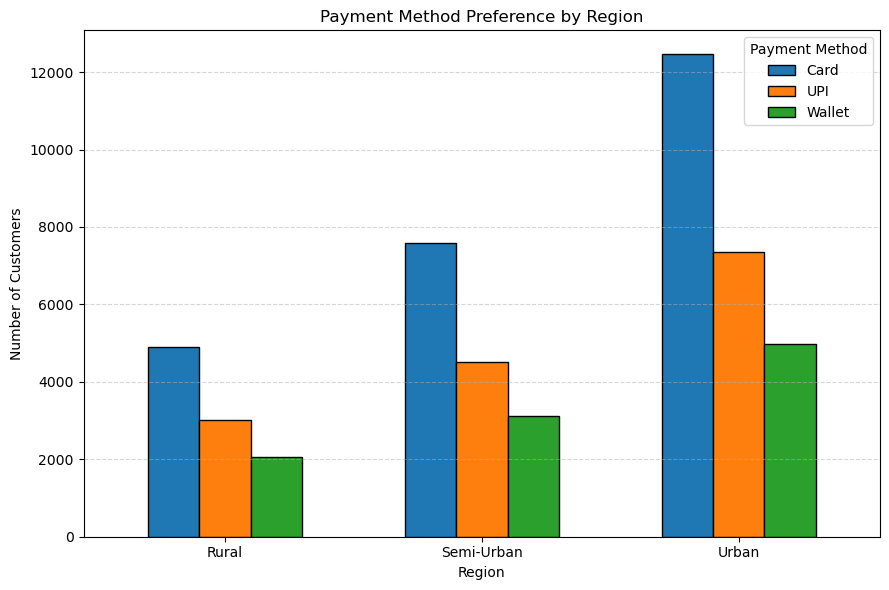

Plot 6 saved.

--- KEY INSIGHTS ---
Region-wise average monthly spend:
region
Rural         334.63
Semi-Urban    334.82
Urban         335.84
Name: avg_monthly_spend, dtype: float64

Most popular payment method overall: Card

Payment method by region:
payment_method   Card   UPI  Wallet
region                             
Rural            4910  3027    2066
Semi-Urban       7588  4511    3113
Urban           12455  7360    4970


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------
# Load dataset
# -----------------------------------------------
df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

# -----------------------------------------------
# FIX: Missing Values (NO WARNING ✔)
# -----------------------------------------------
num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# -----------------------------------------------
# PLOT 1: Customer Count by Region — Bar Chart
# -----------------------------------------------
region_counts = df['region'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2980b9', '#27ae60', '#e67e22']

bars = ax.bar(region_counts.index, region_counts.values,
              color=colors, edgecolor='black')

for bar, val in zip(bars, region_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            str(val),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_xlabel('Region')
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Distribution by Region')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot5_customers_by_region.png', dpi=150)
plt.show()

print("Plot 5 saved.")

# -----------------------------------------------
# PLOT 2: Payment Method Preference by Region
# -----------------------------------------------
payment_region = df.groupby(['region', 'payment_method']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 6))

payment_region.plot(kind='bar', ax=ax,
                    edgecolor='black', width=0.6)

ax.set_xlabel('Region')
ax.set_ylabel('Number of Customers')
ax.set_title('Payment Method Preference by Region')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Payment Method')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot6_payment_by_region.png', dpi=150)
plt.show()

print("Plot 6 saved.")

# -----------------------------------------------
# INSIGHT SUMMARY
# -----------------------------------------------
print("\n--- KEY INSIGHTS ---")

print("Region-wise average monthly spend:")
print(df.groupby('region')['avg_monthly_spend'].mean().round(2))

print("\nMost popular payment method overall:",
      df['payment_method'].value_counts().idxmax())

print("\nPayment method by region:")
print(payment_region)

OBJECTIVE 4: Do High_Value customers spend significantly more than Occasional customers?

High Value customers : 5273
Occasional customers : 22109
Avg spend — High Value : ₹463.77
Avg spend — Occasional : ₹381.60

--- T-TEST RESULTS ---
T-statistic : 24.9360
P-value     : 0.000000

Result: Reject H0 (p < 0.05)
Conclusion: High Value customers spend significantly more.


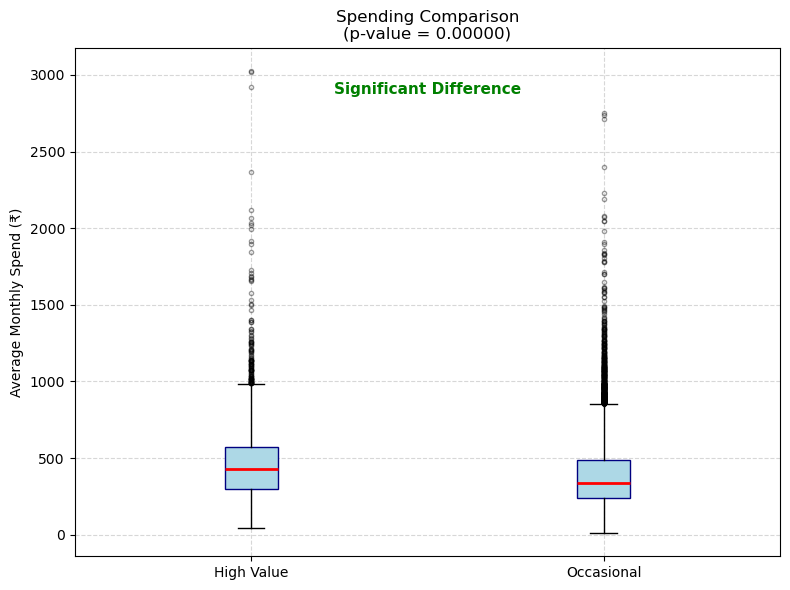

Hypothesis test plot saved.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------------------------
# Load dataset
# -----------------------------------------------
df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

# -----------------------------------------------
# FIX 1: Missing Values (NO WARNING ✔)
# -----------------------------------------------
num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']

# ✅ Replace loop + inplace
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# -----------------------------------------------
# Data Selection
# -----------------------------------------------
high_value = df[df['customer_segment'] == 'High_Value']['avg_monthly_spend']
occasional = df[df['customer_segment'] == 'Occasional']['avg_monthly_spend']

print(f"High Value customers : {len(high_value)}")
print(f"Occasional customers : {len(occasional)}")
print(f"Avg spend — High Value : ₹{high_value.mean():.2f}")
print(f"Avg spend — Occasional : ₹{occasional.mean():.2f}")

# -----------------------------------------------
# T-Test
# -----------------------------------------------
t_stat, p_value = stats.ttest_ind(high_value, occasional)

print("\n--- T-TEST RESULTS ---")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: Reject H0 (p < {alpha})")
    print("Conclusion: High Value customers spend significantly more.")
else:
    print(f"\nResult: Fail to Reject H0 (p >= {alpha})")
    print("Conclusion: No significant difference.")

# -----------------------------------------------
# FIX 2: Boxplot (NO WARNING ✔)
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot([high_value, occasional],
           tick_labels=['High Value', 'Occasional'],  # ✅ fixed
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markersize=3, alpha=0.4))

ax.set_ylabel('Average Monthly Spend (₹)')
ax.set_title(f'Spending Comparison\n(p-value = {p_value:.5f})')
ax.grid(True, linestyle='--', alpha=0.5)

result_text = "Significant Difference" if p_value < 0.05 else "No Significant Difference"

ax.text(1.5, max(high_value.max(), occasional.max()) * 0.95,
        result_text,
        ha='center',
        fontsize=11,
        color='green' if p_value < 0.05 else 'red',
        fontweight='bold')

plt.tight_layout()
plt.savefig('plot7_hypothesis_test.png', dpi=150)
plt.show()

print("Hypothesis test plot saved.")

OBJECTIVE 5: Can we predict a customer's average monthly spend using their behavioral and demographic features?

--- MODEL EVALUATION ---
R² Score : -0.0002
MAE      : 146.4851 (₹)

--- FEATURE COEFFICIENTS ---
              Feature  Coefficient
   purchase_frequency     0.584556
browsing_time_minutes     0.002002
        annual_income    -0.000023
        months_active    -0.007327
  discount_usage_rate    -1.011584


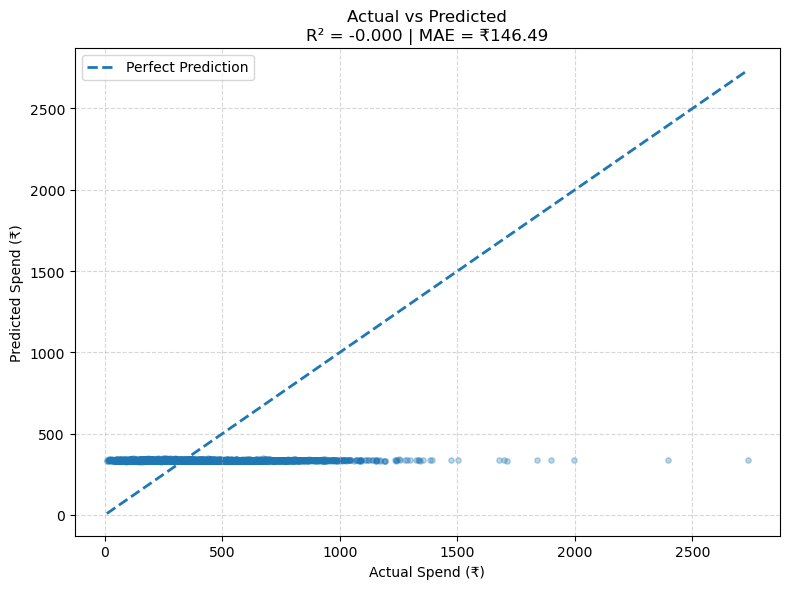

Plot saved.


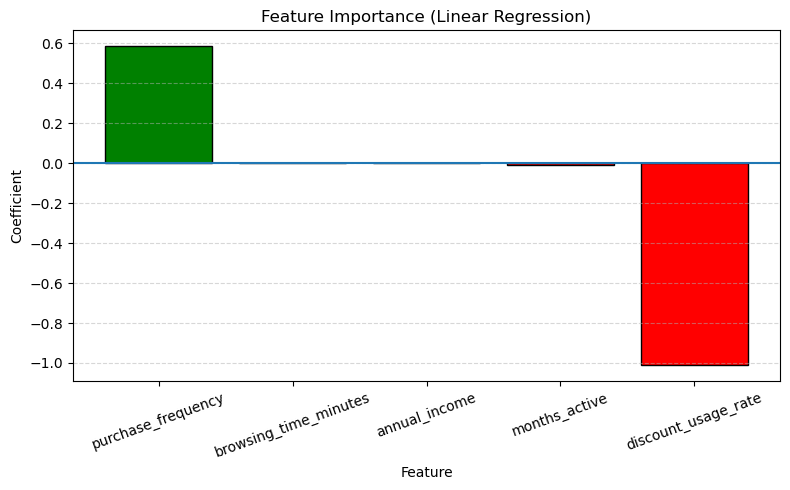

Coefficients plot saved.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# -----------------------------------------------
# Load dataset
# -----------------------------------------------
df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

# -----------------------------------------------
# FIX: Missing Values (NO WARNING ✔)
# -----------------------------------------------
num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# -----------------------------------------------
# Define features and target
# -----------------------------------------------
features = ['annual_income', 'purchase_frequency', 'browsing_time_minutes',
            'discount_usage_rate', 'months_active']

target = 'avg_monthly_spend'

X = df[features]
y = df[target]

# -----------------------------------------------
# Train-Test Split
# -----------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------------------------
# Train Model
# -----------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------------------------
# Evaluate
# -----------------------------------------------
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- MODEL EVALUATION ---")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f} (₹)")

# -----------------------------------------------
# Feature Importance
# -----------------------------------------------
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n--- FEATURE COEFFICIENTS ---")
print(coeff_df.to_string(index=False))

# -----------------------------------------------
# PLOT 1: Actual vs Predicted
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred, alpha=0.3, s=15)

ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle='--', linewidth=2,
        label='Perfect Prediction')

ax.set_xlabel('Actual Spend (₹)')
ax.set_ylabel('Predicted Spend (₹)')
ax.set_title(f'Actual vs Predicted\nR² = {r2:.3f} | MAE = ₹{mae:.2f}')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot8_actual_vs_predicted.png', dpi=150)
plt.show()

print("Plot saved.")

# -----------------------------------------------
# PLOT 2: Feature Coefficients
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['green' if c > 0 else 'red' for c in coeff_df['Coefficient']]

ax.bar(coeff_df['Feature'], coeff_df['Coefficient'],
       color=colors, edgecolor='black')

ax.axhline(0)
ax.set_xlabel('Feature')
ax.set_ylabel('Coefficient')
ax.set_title('Feature Importance (Linear Regression)')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot9_coefficients.png', dpi=150)
plt.show()

print("Coefficients plot saved.")

OBJECTIVE 6: Which customer variables are most strongly correlated with each other, and what drives monthly spend the most?

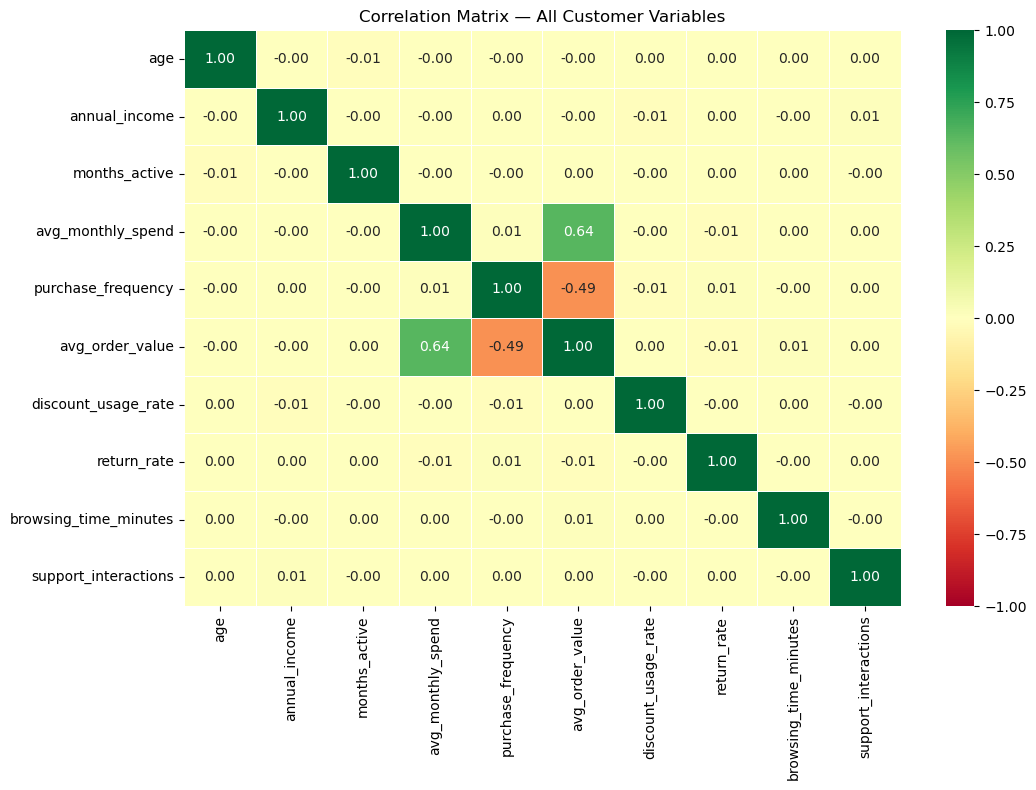

Correlation heatmap saved.


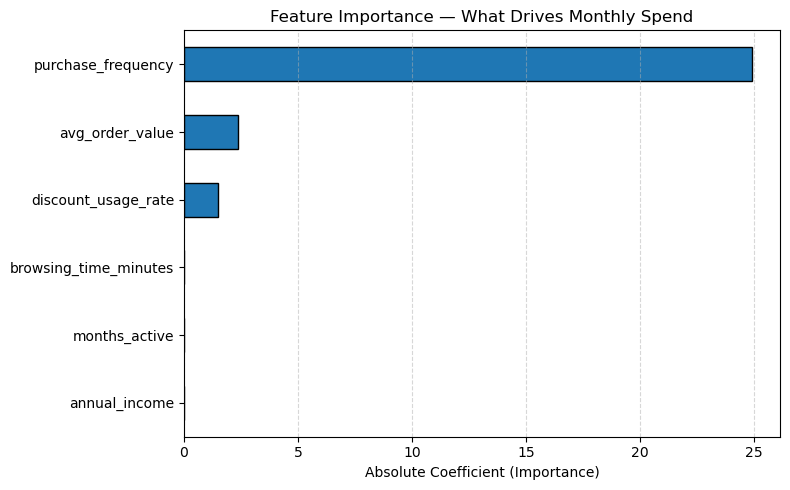

Feature importance plot saved.


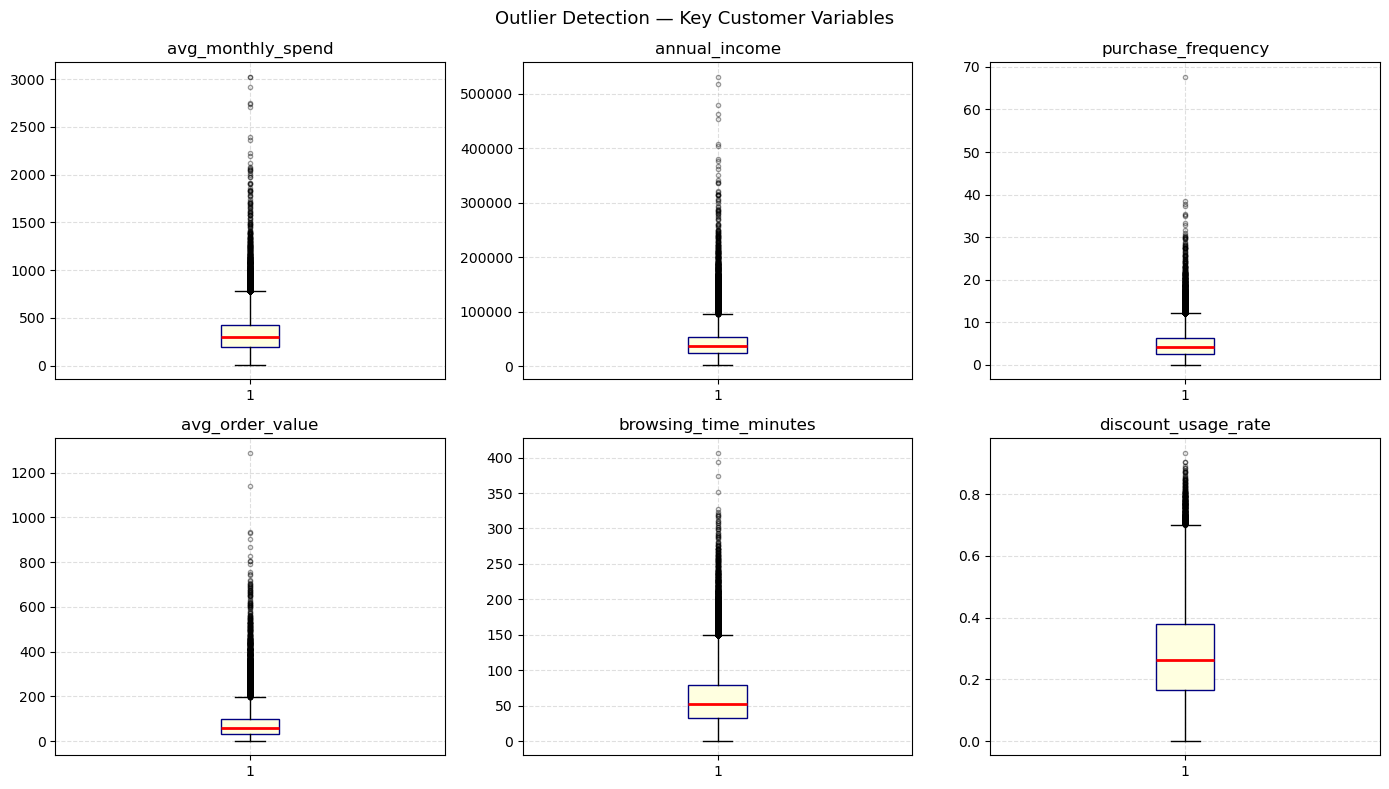

Outlier boxplots saved.

--- KEY INSIGHTS ---
Variables most correlated with avg_monthly_spend:
avg_order_value          0.64
purchase_frequency       0.01
age                     -0.00
annual_income           -0.00
months_active           -0.00
discount_usage_rate     -0.00
browsing_time_minutes    0.00
support_interactions     0.00
return_rate             -0.01
Name: avg_monthly_spend, dtype: float64

Most important feature for predicting spend: purchase_frequency


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# -----------------------------------------------
# Load dataset
# -----------------------------------------------
df = pd.read_csv(r"C:\Users\hp\Downloads\retail_customer_segmentation.csv")

# -----------------------------------------------
# FIX: Missing Values (NO WARNING ✔)
# -----------------------------------------------
num_cols_fill = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
                 'discount_usage_rate', 'return_rate',
                 'browsing_time_minutes', 'support_interactions']

df[num_cols_fill] = df[num_cols_fill].fillna(df[num_cols_fill].median())

# -----------------------------------------------
# Numeric columns
# -----------------------------------------------
numeric_cols = ['age', 'annual_income', 'months_active', 'avg_monthly_spend',
                'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
                'return_rate', 'browsing_time_minutes', 'support_interactions']

# -----------------------------------------------
# PLOT 1: Correlation Heatmap
# -----------------------------------------------
corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, center=0, vmin=-1, vmax=1)

ax.set_title('Correlation Matrix — All Customer Variables')

plt.tight_layout()
plt.savefig('plot10_full_correlation.png', dpi=150)
plt.show()

print("Correlation heatmap saved.")

# -----------------------------------------------
# PLOT 2: Feature Importance
# -----------------------------------------------
features = ['annual_income', 'purchase_frequency', 'browsing_time_minutes',
            'discount_usage_rate', 'months_active', 'avg_order_value']

target = 'avg_monthly_spend'

X = df[features]
y = df[target]

model = LinearRegression()
model.fit(X, y)

importance = pd.Series(np.abs(model.coef_), index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

importance.plot(kind='barh', ax=ax, edgecolor='black')

ax.set_xlabel('Absolute Coefficient (Importance)')
ax.set_title('Feature Importance — What Drives Monthly Spend')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot11_feature_importance.png', dpi=150)
plt.show()

print("Feature importance plot saved.")

# -----------------------------------------------
# PLOT 3: Outlier Detection
# -----------------------------------------------
cols_to_check = ['avg_monthly_spend', 'annual_income', 'purchase_frequency',
                 'avg_order_value', 'browsing_time_minutes', 'discount_usage_rate']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightyellow', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(col)
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Outlier Detection — Key Customer Variables', fontsize=13)

plt.tight_layout()
plt.savefig('plot12_outliers_boxplot.png', dpi=150)
plt.show()

print("Outlier boxplots saved.")

# -----------------------------------------------
# INSIGHTS
# -----------------------------------------------
print("\n--- KEY INSIGHTS ---")

corr_with_spend = corr['avg_monthly_spend'].drop('avg_monthly_spend').sort_values(ascending=False)

print("Variables most correlated with avg_monthly_spend:")
print(corr_with_spend)

print("\nMost important feature for predicting spend:", importance.idxmax())